<a href="https://colab.research.google.com/github/anurimaghosal/Amazon-Prime-EDA-Visualization/blob/main/Amazon_Prime_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import files
uploaded1 = files.upload()

Saving titles.csv.zip to titles.csv.zip


In [5]:

uploaded2 = files.upload()

Saving credits.csv.zip to credits.csv.zip


In [6]:
import zipfile

with zipfile.ZipFile('titles.csv.zip', 'r') as zip_ref:
    zip_ref.extractall()

with zipfile.ZipFile('credits.csv.zip', 'r') as zip_ref:
    zip_ref.extractall()

In [8]:
import pandas as pd
titles = pd.read_csv('titles.csv')
credits = pd.read_csv('credits.csv')

In [9]:
titles.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,NaN,171,"['romance', 'war', 'drama']",['US'],NaN,tt0036868,8.1,63026.0,8.435,7.8
3,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper...",1940,NaN,92,"['comedy', 'drama', 'romance']",['US'],NaN,tt0032599,7.8,57835.0,11.270,7.4
4,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her...,1950,NaN,94,"['thriller', 'drama', 'romance']",['US'],NaN,tt0042593,7.9,30924.0,8.273,7.6


In [10]:
credits.head()

,person_id,id,name,character,role
0,59401,ts20945,Joe Besser,Joe,ACTOR
1,31460,ts20945,Moe Howard,Moe,ACTOR
2,31461,ts20945,Larry Fine,Larry,ACTOR
3,21174,tm19248,Buster Keaton,Johnny Gray,ACTOR
4,28713,tm19248,Marion Mack,Annabelle Lee,ACTOR


In [11]:
titles.shape
credits.shape

(124235, 5)

In [12]:
merged_df = titles.merge(credits, on='id')

In [13]:
merged_df.head()

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score,person_id,name,character,role
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,59401,Joe Besser,Joe,ACTOR
1,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,31460,Moe Howard,Moe,ACTOR
2,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"['comedy', 'family', 'animation', 'action', 'f...",['US'],26.0,tt0850645,8.6,1092.0,15.424,7.6,31461,Larry Fine,Larry,ACTOR
3,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0,21174,Buster Keaton,Johnny Gray,ACTOR
4,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,NaN,78,"['action', 'drama', 'war', 'western', 'comedy'...",['US'],NaN,tt0017925,8.2,89766.0,8.647,8.0,28713,Marion Mack,Annabelle Lee,ACTOR


In [14]:
merged_df.drop(columns=['age_certification'], inplace=True)

In [15]:
merged_df.columns

Index(['id', 'title', 'type', 'description', 'release_year', 'runtime',
       'genres', 'production_countries', 'seasons', 'imdb_id', 'imdb_score',
       'imdb_votes', 'tmdb_popularity', 'tmdb_score', 'person_id', 'name',
       'character', 'role'],
      dtype='object')

In [16]:
merged_df.drop(columns=['seasons'],inplace=True)

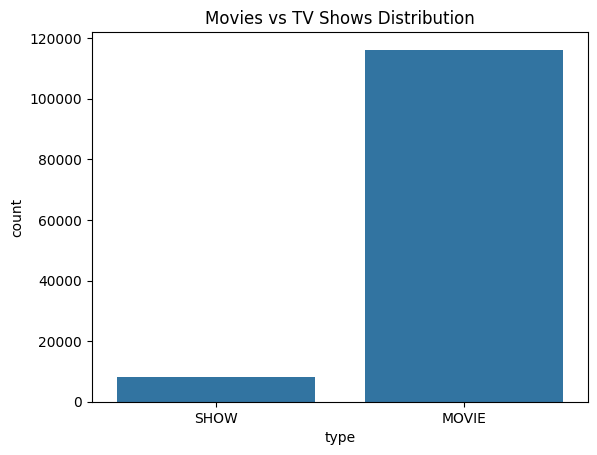

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='type', data=merged_df)
plt.title("Movies vs TV Shows Distribution")
plt.show()

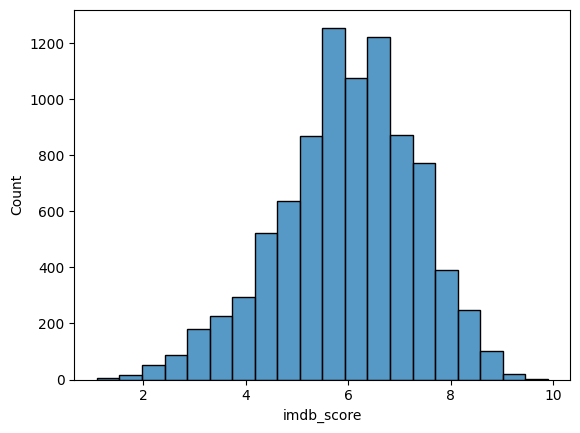

In [ ]:
sns.histplot(titles['imdb_score'], bins=20)
plt.show()

In [ ]:
actors_df = merged_df[merged_df['role'] == 'ACTOR']

In [ ]:
actor_movie_count = actors_df['name'].value_counts()

In [ ]:
actors_2plus = actor_movie_count[actor_movie_count >= 2]

In [ ]:
actors_2plus.head(20)

,count
name,
George 'Gabby' Hayes,49
Roy Rogers,45
Bess Flowers,44
Gene Autry,40
Charles King,38
Nassar,37
Herman Hack,35
George Morrell,34
Forrest Taylor,34


Content Release Trend Over Years

In [17]:
df=merged_df.copy();

In [25]:
print(df['genres'].unique())

["['comedy'" "'family'" "'animation'" "'action'" "'fantasy'" "'horror']"
 "['action'" "'drama'" "'war'" "'western'" "'comedy'" "'european']"
 "['romance'" "'drama']" "'romance']" "['thriller'" "['western'"
 "['drama'" "'romance'" "'comedy']" "'crime']" "['crime'" "['history'"
 "'crime'" "['horror']" "'horror'" "'action']" "'thriller'" "'sport']"
 "['scifi'" "'war']" "'fantasy']" "['fantasy'" "'family']" "['comedy']"
 "['western']" "'scifi']" "['drama']" "'history'" "['horror'"
 "['documentation'" "'thriller']" "'scifi'" "['war'" "'documentation']"
 "'documentation'" "'history']" "'music'" "['music'" "['reality'"
 "['crime']" "['music']" "'music']" "['action']" "'sport'" "['family'"
 "'western']" "['thriller']" "['romance']" '[]' "['documentation']"
 "'animation']" "['sport'" "'european'" "['animation'" "['scifi']"
 "['family']" "'reality']" "['fantasy']" "['european'" "['animation']"
 "['reality']" "['history']" "'reality'" "['war']" "['sport']"]


In [27]:

df['genres'] = df['genres'].str.replace('[', '', regex=False)
df['genres'] = df['genres'].str.replace(']', '', regex=False)
df['genres'] = df['genres'].str.replace("'", "", regex=False)

df['genres'] = df['genres'].str.split(',')

df = df.explode('genres')

df['genres'] = df['genres'].str.strip().str.lower()

df = df[df['genres'] != '']

Popularity of each genre over the years

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


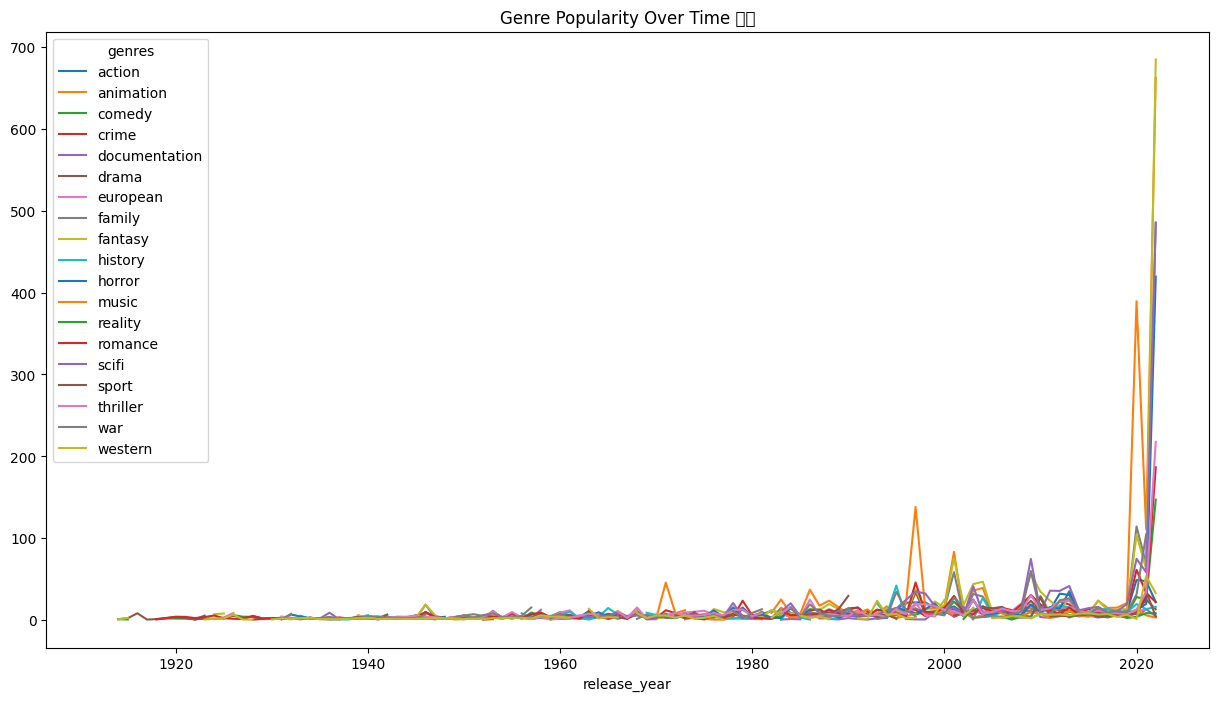

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

df = df.dropna(subset=['genres'])

df['genres'] = df['genres'].str.split(',')

df = df.explode('genres')

df['genres'] = df['genres'].str.strip()

df['tmdb_popularity'] = pd.to_numeric(df['tmdb_popularity'], errors='coerce')genre_popularity = df.groupby(['release_year','genres'])['tmdb_popularity'].mean().reset_index()

pivot_df = genre_popularity.pivot(index='release_year', columns='genre', values='tmdb_popularity')

pivot_df.plot(figsize=(15,8))

plt.title("Genre Popularity Over Time ")
plt.show()

Popularity pattern of each genre from year 2000

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


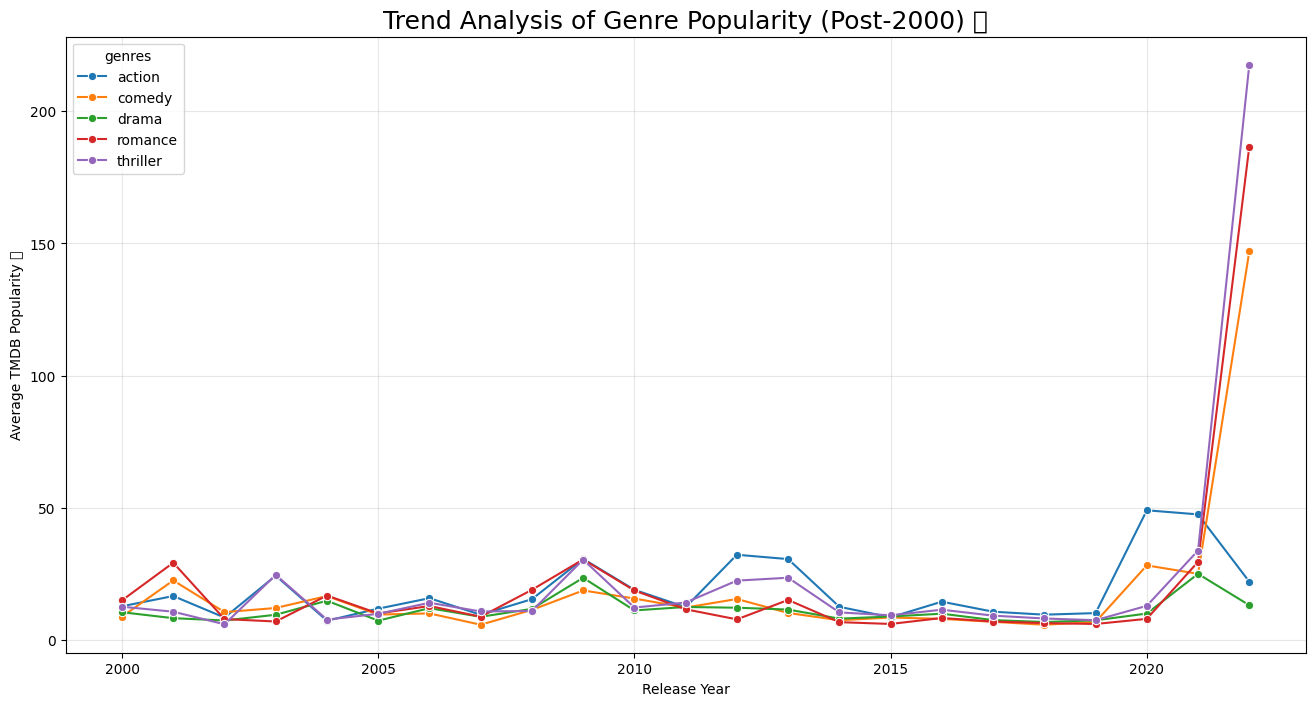

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# recent data
recent_df = df[df['release_year'] >= 2000]

# group
trend = recent_df.groupby(['release_year','genres'])['tmdb_popularity'].mean().reset_index()

# take top genres
top_genres = df['genres'].value_counts().head(5).index
trend = trend[trend['genres'].isin(top_genres)]

plt.figure(figsize=(16,8))

sns.lineplot(
    data=trend,
    x='release_year',
    y='tmdb_popularity',
    hue='genres',
    marker='o'
)

plt.title("Trend Analysis of Genre Popularity (Post-2000)", fontsize=18)
plt.xlabel("Release Year")
plt.ylabel("Average TMDB Popularity ")
plt.grid(alpha=0.3)

plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


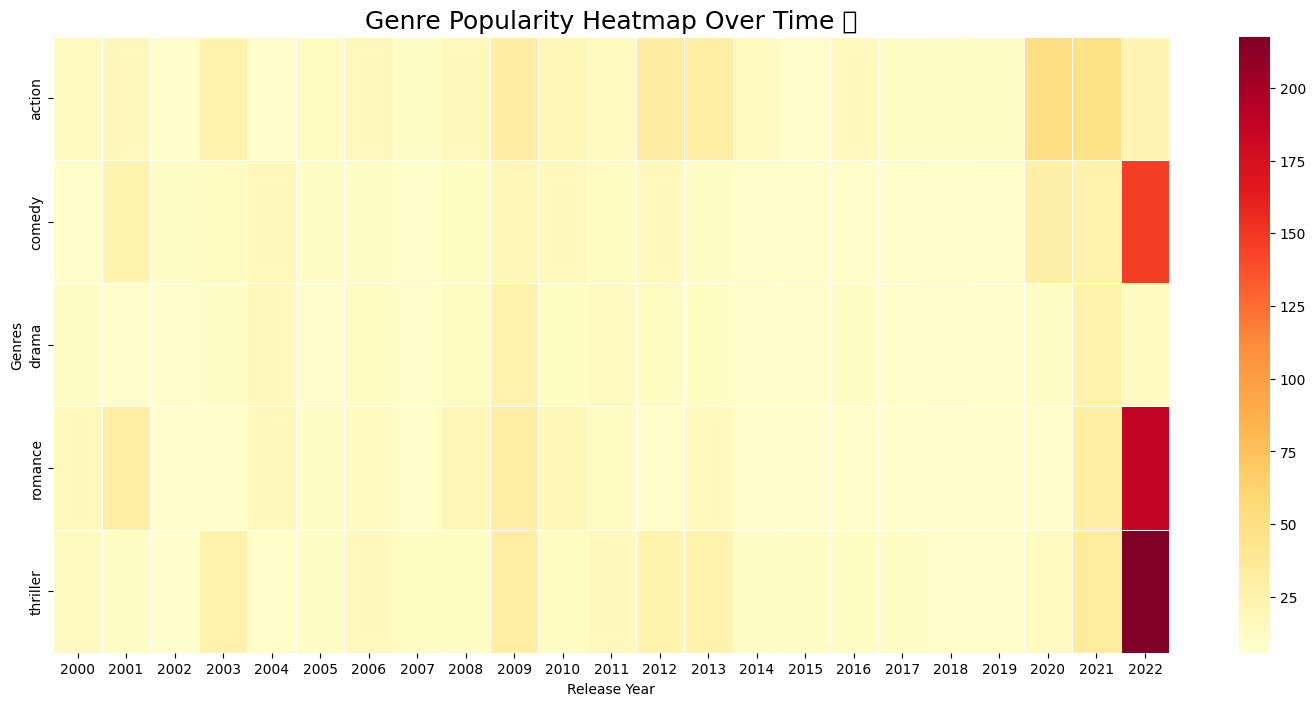

In [34]:
heatmap_data = trend.pivot(index='genres', columns='release_year', values='tmdb_popularity')

plt.figure(figsize=(18,8))

sns.heatmap(
    heatmap_data,
    cmap='YlOrRd',
    linewidths=0.5
)

plt.title("Genre Popularity Heatmap Over Time ", fontsize=18)
plt.xlabel("Release Year")
plt.ylabel("Genres")

plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


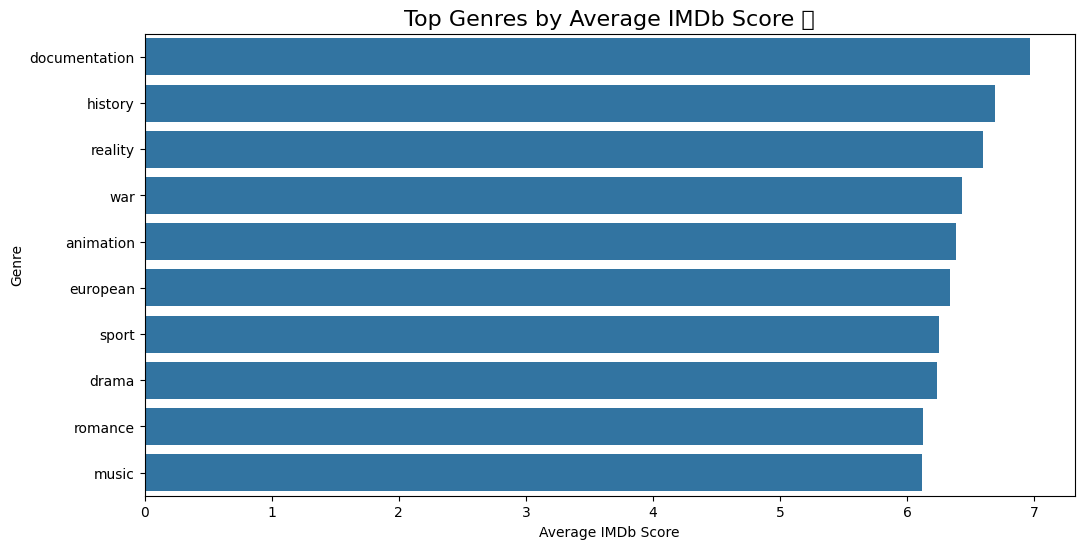

In [39]:
genre_score_df = df[['genres','imdb_score']].dropna()

avg_score = genre_score_df.groupby('genres')['imdb_score'].mean().reset_index()
avg_score = avg_score.sort_values(by='imdb_score', ascending=False).head(10)
plt.figure(figsize=(12,6))
sns.barplot(
    data=avg_score,
    x='imdb_score',
    y='genres'
)
plt.title("Top Genres by Average IMDb Score ⭐", fontsize=16)
plt.xlabel("Average IMDb Score")
plt.ylabel("Genre")

plt.show()

Top actor per Genre

In [41]:

actor_df = df[['name','genres','title']].dropna()

actor_genre_count = actor_df.groupby(['genres','name'])['title'].count().reset_index()

actor_genre_count.rename(columns={'title':'movie_count'}, inplace=True)

top_actor_per_genre = actor_genre_count.sort_values(
    ['genres','movie_count'],
    ascending=[True, False]
).drop_duplicates('genres')

top_actor_per_genre

,genres,name,movie_count
10494,action,Joseph Kane,38
24945,animation,Takahiro Sakurai,11
38567,comedy,Jay Chapman,34
70879,crime,Sam Newfield,11
78983,documentation,Steven 'Prozak' Shippy,12
113628,drama,Nassar,27
133376,european,Guillaume Canet,6
142858,family,Frank Welker,8
150443,fantasy,Frank Welker,8
158019,history,Frank Capra,5


<Axes: title={'center': 'Number of Movies Released Trend over the years'}, xlabel='release_year'>

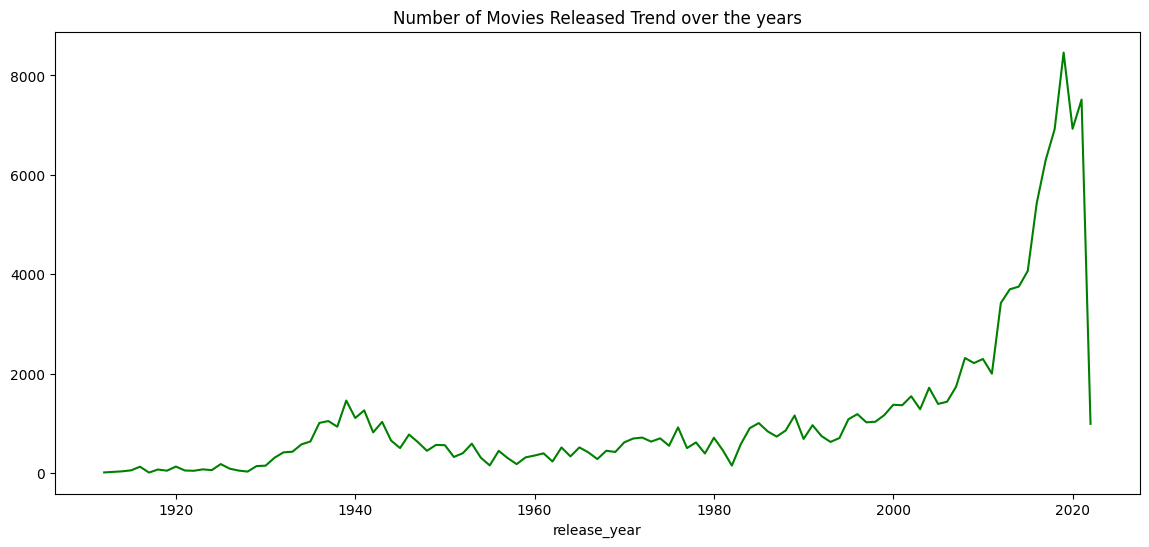

In [21]:
movies_per_year = df.groupby('release_year')['title'].count()
movies_per_year.plot(kind='line', figsize=(14,6), color='green', title="Number of Movies Released Trend over the years")

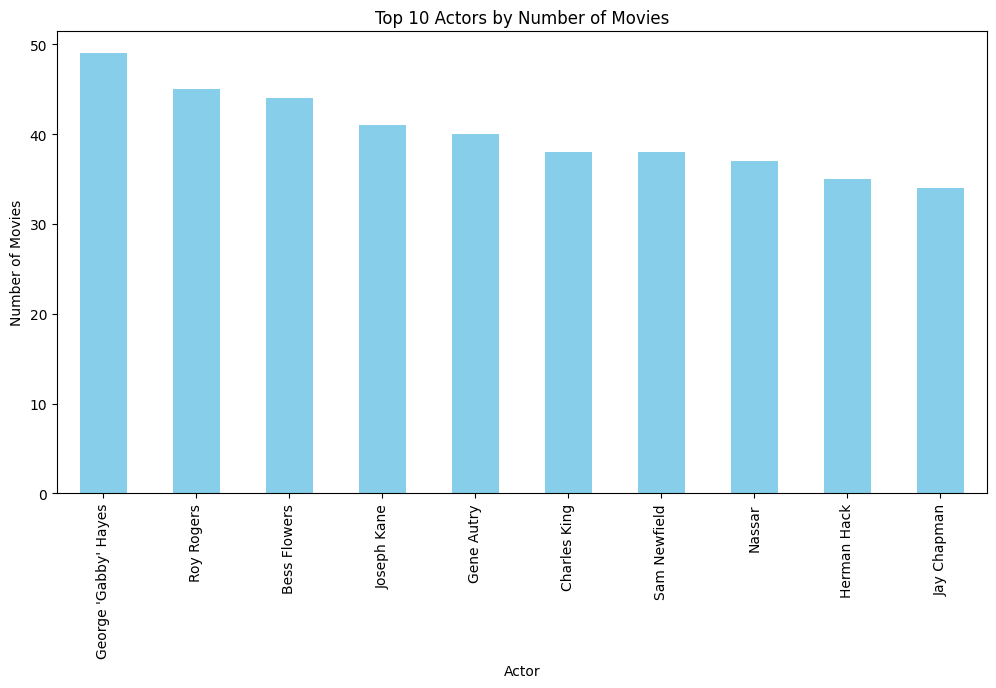

In [27]:
# Most active actors
top_actors = df.groupby('name')['title'].count().sort_values(ascending=False).head(10)

# Plot
top_actors.plot(kind='bar', figsize=(12,6), color='skyblue', title="Top 10 Actors by Number of Movies")
plt.xlabel("Actor")
plt.ylabel("Number of Movies")
plt.show()